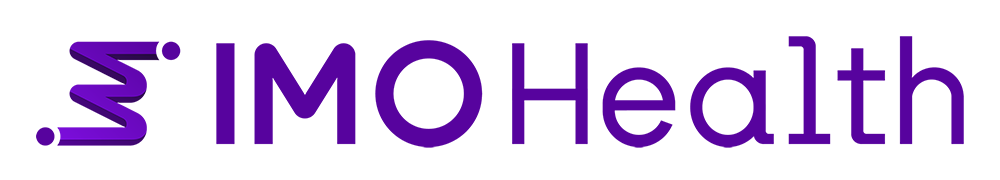

---

---
## IMO Health — Enrichment Normalization
### Product: IMO Precision Normalize (Enrichment API)

**Enrichment Normalization** is a context-aware variant of base normalization, designed exclusively for the **problem / diagnosis** domain. By providing a clinical note snippet alongside each term, the API resolves ambiguous or vague terms to the most specific IMO lexical code — for example, distinguishing *"Type 2 Diabetes with diabetic nephropathy"* from a plain *"diabetes"* entry.

This notebook calls the **IMO Precision Normalize API directly** — no local Flask server required.

---

### When to use Enrichment vs Base Normalization

| | Base Normalization | Enrichment Normalization |
|---|---|---|
| **Domains** | problem, procedure, medication, lab | **problem only** |
| **Input** | `term` + `domain` | `term` + `domain` + **`context`** |
| **Resolution** | Broad term → best IMO match | Context-guided → most specific IMO match |
| **Use case** | Structured data, coded lists | Free-text clinical notes, discharge summaries |

### What you'll cover
1. Install packages and load credentials from `config.json`
2. Obtain an IMO OAuth bearer token
3. Define problem entities with clinical note context
4. Submit to the IMO Precision Normalize Enrichment API
5. Review and compare enriched vs base results
6. Export `normalized_codes` for downstream use

> 💡 **Prerequisite:** Copy `config.json.template` → `config.json` and fill in your `client_id` and `client_secret` for the Precision Normalize service.

## Step 1: Install Packages & Load Credentials

In [ ]:
%pip install requests pandas --quiet

import requests
import json
import uuid
import time
import pathlib
import pandas as pd
from IPython.display import display

# ── Load config.json ─────────────────────────────────────────────────────────
_candidates = [
    pathlib.Path("config.json"),
    pathlib.Path(__file__).parent / "config.json" if "__file__" in dir() else None,
    pathlib.Path.cwd() / "config.json",
    pathlib.Path.cwd().parent / "config.json",
]
_cfg_path = next((p for p in _candidates if p and p.exists()), None)

if _cfg_path is None:
    raise FileNotFoundError(
        "config.json not found. Copy config.json.template → config.json and fill in your credentials."
    )

with open(_cfg_path) as _f:
    _cfg = json.load(_f)

_creds = _cfg.get("precision_normalize", {})
CLIENT_ID     = _creds.get("client_id", "")
CLIENT_SECRET = _creds.get("client_secret", "")

AUTH_URL      = _creds.get("token_url",   "https://api.imohealth.com/oauth/token")
ENRICH_URL    = "https://api.imohealth.com/precision/normalize/enrichment"
BASE_NORM_URL = "https://api.imohealth.com/precision/normalize"

print(f"✓ config.json loaded from: {_cfg_path.resolve()}")
print(f"  client_id configured : {'✓' if CLIENT_ID and CLIENT_ID != '<YOUR_PRECISION_NORMALIZE_CLIENT_ID>' else '✗ not set'}")
print(f"  client_secret        : {'✓' if CLIENT_SECRET and CLIENT_SECRET != '<YOUR_PRECISION_NORMALIZE_CLIENT_SECRET>' else '✗ not set'}")

---
## Step 2: Obtain IMO OAuth Bearer Token

The IMO API uses **OAuth 2.0 client credentials**. The token is valid for ~18 hours and is auto-refreshed if expired.

In [ ]:
_token_cache = {"token": None, "expiry": 0}

def get_token() -> str:
    """Return a valid IMO bearer token, refreshing if expired."""
    if _token_cache["token"] and time.time() < _token_cache["expiry"]:
        return _token_cache["token"]

    resp = requests.post(AUTH_URL, json={
        "grant_type":    "client_credentials",
        "client_id":     CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "audience":      "https://api.imohealth.com",
    }, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    _token_cache["token"]  = data["access_token"]
    _token_cache["expiry"] = time.time() + data.get("expires_in", 3600) - 60
    return _token_cache["token"]

def auth_headers() -> dict:
    return {"Authorization": f"Bearer {get_token()}", "Content-Type": "application/json"}

# Verify token
token = get_token()
print(f"✓ Bearer token obtained (first 20 chars): {token[:20]}...")

---
## Step 3: Define Entities with Clinical Context

Each entity **must** include:
- `"term"` — the raw clinical term (e.g., `"diabetes"`, `"chest pain"`)
- `"domain"` — must be `"problem"` (enrichment is diagnosis-domain only)
- `"context"` — a clinical note snippet (1–3 sentences) that surrounds the term

The `context` field drives specificity. The richer the note snippet, the more precise the resolved IMO code.

> **Tip:** Paste real note text directly into the `context` field. The API is designed to handle messy, unstructured clinical language.

In [ ]:
# ── Define enrichment entities ──────────────────────────────────────────────
# Each entity: term + domain (must be "problem") + context (clinical note snippet)
# Add, remove, or edit entries to match your use case.

enrichment_entities = [
    {
        "term":    "diabetes",
        "domain":  "problem",
        "context": "58-year-old male with poorly controlled Type 2 Diabetes Mellitus, "
                   "HbA1c 9.1%. Currently on Metformin 1000mg BID and Jardiance 10mg. "
                   "Diabetic nephropathy documented. Kidney function declining.",
    },
    {
        "term":    "hypertension",
        "domain":  "problem",
        "context": "Essential hypertension, BP 148/92 mmHg at today's visit. "
                   "On Lisinopril 20mg daily. No secondary cause identified.",
    },
    {
        "term":    "chest pain",
        "domain":  "problem",
        "context": "Patient presents with exertional chest pain, worse with activity, "
                   "relieved by rest. EKG shows ST depression in leads V4-V6. "
                   "Troponin mildly elevated. Suspected unstable angina.",
    },
    {
        "term":    "anemia",
        "domain":  "problem",
        "context": "Normocytic normochromic anemia in the setting of chronic kidney disease stage 3. "
                   "Hgb 9.2 g/dL, MCV 88. Likely anemia of chronic disease.",
    },
    {
        "term":    "shortness of breath",
        "domain":  "problem",
        "context": "Progressive dyspnea on exertion over 3 months. "
                   "Echo shows EF 35%, dilated cardiomyopathy. "
                   "Bilateral crackles on exam. Impression: acute decompensated heart failure.",
    },
]

print(f"✓ {len(enrichment_entities)} enrichment entities defined")
for e in enrichment_entities:
    print(f"  · {e['term']}")

---
## Step 4: Submit to IMO Enrichment Normalization API

Sends all entities directly to `POST https://api.imohealth.com/precision/normalize/enrichment`. Each entity is routed through the context-aware model and returns the most specific IMO lexical match along with standard code mappings.

In [ ]:
def enrich_normalize(entities: list) -> list:
    """Call the IMO Precision Normalize enrichment endpoint for problem entities."""
    results = []
    for e in entities:
        payload = {
            "organization_id":   "IMO",
            "client_request_id": str(uuid.uuid4()),
            "preferences": {"threshold": 0.0, "match_field_pref": "input_term"},
            "requests": [{
                "record_id": str(uuid.uuid4()),
                "domain":    e["domain"],
                "input_term": e["term"],
                "context": {"source_text": e.get("context", "")},
            }],
        }
        resp = requests.post(ENRICH_URL, headers=auth_headers(), json=payload, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        items = (data.get("requests") or [{}])[0].get("response", {}).get("items", [])
        top   = items[0] if items else {}
        meta  = top.get("metadata", {})
        maps  = meta.get("mappings", {})
        flags = meta.get("flags", {})

        icd_codes = maps.get("icd10cm", {}).get("codes", [])

        results.append({
            "original_term":    e["term"],
            "imo_lexical_code": top.get("lexical_code", ""),
            "imo_lexical_title": top.get("lexical_title", top.get("title", "")),
            "icd10cm_code":     icd_codes[0].get("code", "") if icd_codes else "",
            "icd10cm_title":    icd_codes[0].get("title", "") if icd_codes else "",
            "snomed_code":      maps.get("snomed", {}).get("codes", [{}])[0].get("code", "") if maps.get("snomed", {}).get("codes") else "",
            "score":            top.get("score", 0.0),
            "is_refineable":    flags.get("is_icd10cm_refinable", False),
            "method":           "enrichment",
        })
    return results


enrich_results = enrich_normalize(enrichment_entities)

print("✓ IMO Precision Normalize — Enrichment Normalization")
print(f"  Entities processed : {len(enrich_results)}\n")

display(pd.DataFrame([{
    "Term (raw)":  r["original_term"],
    "IMO Code":    r["imo_lexical_code"],
    "IMO Title":   r["imo_lexical_title"],
    "ICD-10-CM":   r["icd10cm_code"],
    "SNOMED CT":   r["snomed_code"],
    "Score":       f"{r['score']:.3f}",
    "Refineable":  "⚠ Yes" if r["is_refineable"] else "✓ No",
} for r in enrich_results]))

---
## Step 5: Compare — Raw Term vs Enriched Result

The cell below runs the same terms through **Base Normalization** (no context) via the IMO API and puts both results side-by-side so you can see the specificity improvement from context enrichment.

In [ ]:
def base_normalize(entities: list) -> list:
    """Call the IMO Precision Normalize base endpoint (no context)."""
    results = []
    for e in entities:
        payload = {
            "organization_id":   "IMO",
            "client_request_id": str(uuid.uuid4()),
            "preferences": {"threshold": 0.0, "match_field_pref": "input_term"},
            "requests": [{
                "record_id":  str(uuid.uuid4()),
                "domain":     e["domain"],
                "input_term": e["term"],
            }],
        }
        resp = requests.post(BASE_NORM_URL, headers=auth_headers(), json=payload, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        items = (data.get("requests") or [{}])[0].get("response", {}).get("items", [])
        top   = items[0] if items else {}
        meta  = top.get("metadata", {})
        maps  = meta.get("mappings", {})
        icd_codes = maps.get("icd10cm", {}).get("codes", [])

        results.append({
            "term":             e["term"],
            "imo_lexical_title": top.get("lexical_title", top.get("title", "")),
            "icd10cm_code":     icd_codes[0].get("code", "") if icd_codes else "",
        })
    return results


base_results_cmp = base_normalize([{"term": e["term"], "domain": e["domain"]} for e in enrichment_entities])
base_lookup = {r["term"].lower(): r for r in base_results_cmp}

comparison_rows = []
for r_e in enrich_results:
    raw   = r_e["original_term"].lower()
    r_b   = base_lookup.get(raw, {})
    comparison_rows.append({
        "Term":               r_e["original_term"].title(),
        "Base IMO Title":     r_b.get("imo_lexical_title", ""),
        "Base ICD-10-CM":     r_b.get("icd10cm_code", ""),
        "Enriched IMO Title": r_e["imo_lexical_title"],
        "Enriched ICD-10-CM": r_e["icd10cm_code"],
        "More Specific?":     "✓" if r_e["icd10cm_code"] != r_b.get("icd10cm_code", "") else "—",
    })

print("Base vs Enrichment Normalization — Side-by-Side Comparison\n")
display(pd.DataFrame(comparison_rows))

---
## Step 6: Review Refineable Concepts

Terms flagged as **refineable** (`is_refineable: true`) indicate that the IMO lexical code is a parent concept and could be mapped to a more specific child code. These are worth reviewing manually or with the IMO Core Search UI for further precision.

In [ ]:
refineable = [r for r in enrich_results if r.get("is_refineable")]

if not refineable:
    print("✓ No refineable concepts — all terms resolved to leaf-level IMO codes.")
else:
    print(f"⚠  {len(refineable)} refineable concept(s) found:\n")
    display(pd.DataFrame([
        {
            "Term":         r.get("original_term") or r.get("term", ""),
            "IMO Code":     r.get("imo_lexical_code") or r.get("imo_code", ""),
            "IMO Title":    r.get("imo_lexical_title") or r.get("imo_description", ""),
            "ICD-10-CM":    r.get("icd10cm_code", ""),
            "Suggestion":   "Consider using IMO Core Search to select a more specific child concept.",
        }
        for r in refineable
    ]))

---
## Step 7: Export Normalized Codes

Produces a `normalized_codes` list in the format expected by `POST /api/match_valueset_codes` — ready to feed into Value Set matching if needed downstream.

In [ ]:
normalized_codes = []
seen = set()

for r in enrich_results:
    name = r.get("imo_lexical_title") or r.get("imo_description", "")
    for code_val, code_sys in [
        (r.get("icd10cm_code"), "ICD-10-CM"),
        (r.get("snomed_code"),  "SNOMED CT"),
    ]:
        if code_val and (code_val, code_sys) not in seen:
            seen.add((code_val, code_sys))
            normalized_codes.append({
                "code":        code_val,
                "code_system": code_sys,
                "name":        name,
                "source":      "enrichment",
            })

print(f"✓ normalized_codes ready — {len(normalized_codes)} unique codes")

systems = {}
for c in normalized_codes:
    systems[c["code_system"]] = systems.get(c["code_system"], 0) + 1
for sys, cnt in systems.items():
    print(f"  {sys:20s}: {cnt}")

print("\nSample (first 5):")
display(pd.DataFrame(normalized_codes[:5]))